In [1]:
# Problem: Detecting fake news with a PassiveAggressive Classifier and TfidfVectorizer

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Step 1: Load the data.
# Download the datsets from Kaggle 'Fake News Detection Datasets' and put in dataset directory.
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")
fake_df.head()



,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [9]:
# Step 2: Prepare the data
fake_df['label'] = 0 # Label 0 is for Fake news
true_df['label'] = 1 # Label 1 is for True news
df = pd.concat([true_df, fake_df], axis=0).reset_index(drop=True)


In [10]:
# Step 3: Preprocess the data: Create feature and target datasets.
X = df['text'] # Feature
y = df['label'] # Target

In [11]:
# Step 4: Convert the text data into numerical form using TfidfVectorizer.
# TfidfVectorizer depicts the importance and uniqueness of the word in the dataset.
tf_idf_vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7) # Ignore if the words appears in 70% or more of the documents.
X_tf_idf = tf_idf_vectorizer.fit_transform(X)

In [12]:
# Step 5: Split the Data.
# Split into 80-20 ratio: Training (80%) and Validation(20%) datasets.
X_train, X_val, y_train, y_val = train_test_split(X_tf_idf, y, test_size=0.2, random_state=42)


In [13]:
# Step 6: Create and train the model
# Each iteration allows the model to learn from mistakes it made in the previous iteration.
# The PassiveAggressiveClassifier gets updated "aggressively" when it misclassifies an example,
# adjusting its decision boundary to fix the mistake.
model = PassiveAggressiveClassifier(max_iter=10)
model.fit(X_train, y_train)

C:\Users\muhid\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,C,1.0
,fit_intercept,True
,max_iter,10
,tol,0.001
,early_stopping,False
,validation_fraction,0.1
,n_iter_no_change,5
,shuffle,True
,verbose,0
,loss,'hinge'
,n_jobs,None


In [14]:
# Step 7: Make prediction and Evaluate
predictions = model.predict(X_val)
accuracy_score = accuracy_score(y_val, predictions)
print("Accuracy score:\n", accuracy_score)
confusion_matrix = confusion_matrix(y_val, predictions)
print("Confusion Matrix:\n", confusion_matrix)
classification_report = classification_report(y_val, predictions)
print("Classfication Report:\n", classification_report)

Accuracy score:
 0.994097995545657
Confusion Matrix:
 [[4620   30]
 [  23 4307]]
Classfication Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      4650
           1       0.99      0.99      0.99      4330

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



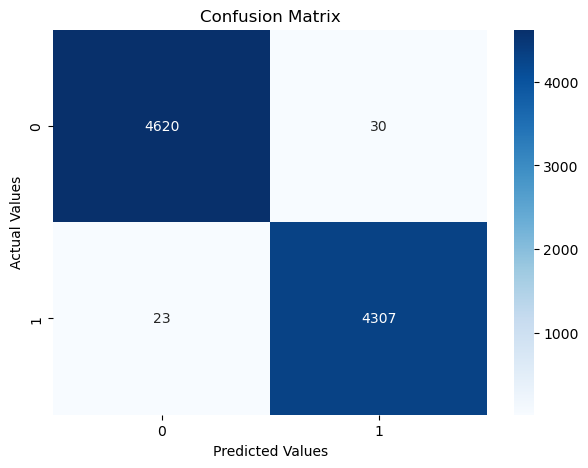

In [15]:
# Step 8: Visualization
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')
plt.show()